In [1]:
from matplotlib import pyplot as plt
from collections import defaultdict

In [5]:
def calculate_stats(vcf_file: str):
    stats = {
        "total_variants": 0,
        "variant_types": defaultdict(int),
        "chromosomes": defaultdict(int),
        "transition_transversion": {"transitions": 0, "transversions": 0},
        "per_sample_ti_tv": defaultdict(int),
    }

    transitions = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}
    sample_names = []

    with open(vcf_file) as vcf:

        for line in vcf:

            if line.startswith("#CHROM"):
                fields = line.strip().split("\t")
                sample_names = fields[9:]

                for sample in sample_names:
                    stats['per_sample_ti_tv'][sample] = {
                        'transitions': 0, 'transversions': 0
                    }
                continue

            elif line.startswith("#"):
                continue

            fields = line.strip().split("\t")
            if len(fields) < 10:
                continue

            chrom, ref, alt = fields[0], fields[3], fields[4].split(',')[0]
            genotypes = fields[9:]

            stats['total_variants'] += 1
            stats['chromosomes'][chrom] += 1

            is_snp = len(ref) == 1 and len(alt) == 1
            if is_snp:
                stats['variant_types']['SNP'] += 1
                change = (ref.upper(), alt.upper())
                is_transition = change in transitions

                if is_transition:
                    stats['transition_transversion']['transitions'] += 1
                else:
                    stats['transition_transversion']['transversions'] += 1

                for sample, gt_field in zip(sample_names, genotypes):
                    gt = gt_field.split(':')[0]
                    if '1' in gt:
                        if is_transition:
                            stats['per_sample_ti_tv'][sample]['transitions'] += 1
                        else:
                            stats['per_sample_ti_tv'][sample]['transversions'] += 1

            elif len(ref) != len(alt):
                stats['variant_types']['INDEL'] += 1

            else:
                stats['variant_types']['OTHER'] += 1

    if stats["transition_transversion"]["transversions"] > 0:
        stats["transition_transversion"]["ratio"] = (
            stats["transition_transversion"]["transitions"]
            / stats["transition_transversion"]["transversions"]
        )
    else:
        stats["transition_transversion"]["ratio"] = "N/A"

    for sample, d in stats["per_sample_ti_tv"].items():
        if d["transversions"] > 0:
            d['ratio'] = d['transitions'] / d['transversions']
        else:
            d['ratio'] = 'N/A'

    return stats

In [6]:
file = "MS_KAZ_WE_125_kaz_samples.MSHC.gold.vcf"
gold_stats = calculate_stats(file)

print(f'Total_variants: {gold_stats["total_variants"]}')
print("\nVariant Types:")
for vtype, count in gold_stats["variant_types"].items():
    print(f"  {vtype}: {count}")
print("\nChromosome Distribution:")
for chrom, count in sorted(gold_stats["chromosomes"].items()):
    print(f"  {chrom}: {count}")

Total_variants: 500376

Variant Types:
  SNP: 442486
  INDEL: 57890

Chromosome Distribution:
  chr1: 51876
  chr10: 22396
  chr11: 29829
  chr12: 21203
  chr13: 9391
  chr14: 14616
  chr15: 16049
  chr16: 20886
  chr17: 25306
  chr18: 8092
  chr19: 27868
  chr2: 37146
  chr20: 14079
  chr21: 7034
  chr22: 12918
  chr3: 30174
  chr4: 22286
  chr5: 25129
  chr6: 24583
  chr7: 27018
  chr8: 20192
  chr9: 21924
  chrX: 10286
  chrY: 95


In [7]:
print("\nTransition/Transversion Statistics:")
ti_tv = gold_stats["transition_transversion"]
print(f"  Transitions: {ti_tv['transitions']}")
print(f"  Transversions: {ti_tv['transversions']}")
print(f"  Ti/Tv ratio: {ti_tv['ratio']}")

print("\nPer-Sample Ti/Tv Ratios:")
for sample, d in gold_stats["per_sample_ti_tv"].items():
    print(f" {sample}: Ti={d['transitions']}, Tv={d['transversions']}, Ratio={d['ratio']}")


Transition/Transversion Statistics:
  Transitions: 310132
  Transversions: 132354
  Ti/Tv ratio: 2.3432008099490758

Per-Sample Ti/Tv Ratios:
 WE001: Ti=68528, Tv=30120, Ratio=2.2751660026560425
 WE002: Ti=66937, Tv=29526, Ratio=2.267052767052767
 WE003: Ti=67809, Tv=29550, Ratio=2.294720812182741
 WE005: Ti=67693, Tv=29764, Ratio=2.274324687541997
 WE006: Ti=67674, Tv=29406, Ratio=2.3013670679453173
 WE007: Ti=67439, Tv=29592, Ratio=2.2789605298729385
 WE008: Ti=68064, Tv=29691, Ratio=2.292411841972315
 WE009: Ti=68137, Tv=29817, Ratio=2.285172887949827
 WE010: Ti=67255, Tv=29635, Ratio=2.2694449131094987
 WE011: Ti=67981, Tv=29909, Ratio=2.2729278812397604
 WE012: Ti=67791, Tv=29339, Ratio=2.3106104502539284
 WE013: Ti=67529, Tv=29654, Ratio=2.277230727726445
 WE015: Ti=67088, Tv=29562, Ratio=2.26939990528381
 WE016: Ti=67611, Tv=29672, Ratio=2.2786128336478835
 WE017: Ti=68438, Tv=30166, Ratio=2.2687131207319498
 WE018: Ti=67266, Tv=29626, Ratio=2.270505636940525
 WE019: Ti=68170, 

In [11]:
post_qc_vcf = '!NEW_ATTEMPT/plink_attempt_2.0/kazakh_exomes.vcf'
post_qc_stats = calculate_stats(post_qc_vcf)
print("\nTransition/Transversion Statistics:")
ti_tv = post_qc_stats["transition_transversion"]
print(f"  Transitions: {ti_tv['transitions']}")
print(f"  Transversions: {ti_tv['transversions']}")
print(f"  Ti/Tv ratio: {ti_tv['ratio']}")

print("\nPer-Sample Ti/Tv Ratios:")
for sample, d in post_qc_stats["per_sample_ti_tv"].items():
    print(f" {sample}: Ti={d['transitions']}, Tv={d['transversions']}, Ratio={d['ratio']}")


Transition/Transversion Statistics:
  Transitions: 40051
  Transversions: 13081
  Ti/Tv ratio: 3.0617689779068877

Per-Sample Ti/Tv Ratios:
 WE001: Ti=10074, Tv=3270, Ratio=3.0807339449541282
 WE002: Ti=10249, Tv=3393, Ratio=3.0206307102858827
 WE003: Ti=10023, Tv=3279, Ratio=3.0567246111619397
 WE005: Ti=10055, Tv=3318, Ratio=3.03044002411091
 WE006: Ti=9982, Tv=3174, Ratio=3.1449275362318843
 WE007: Ti=9958, Tv=3316, Ratio=3.0030156815440288
 WE008: Ti=10130, Tv=3165, Ratio=3.2006319115323856
 WE009: Ti=10341, Tv=3406, Ratio=3.0361127422196126
 WE010: Ti=9880, Tv=3234, Ratio=3.0550401978973407
 WE011: Ti=9943, Tv=3252, Ratio=3.05750307503075
 WE012: Ti=10067, Tv=3195, Ratio=3.1508607198748044
 WE013: Ti=9798, Tv=3225, Ratio=3.038139534883721
 WE015: Ti=9992, Tv=3278, Ratio=3.048200122025625
 WE016: Ti=10304, Tv=3277, Ratio=3.1443393347574
 WE017: Ti=10195, Tv=3400, Ratio=2.998529411764706
 WE018: Ti=10041, Tv=3351, Ratio=2.996418979409132
 WE020: Ti=10025, Tv=3218, Ratio=3.115288999

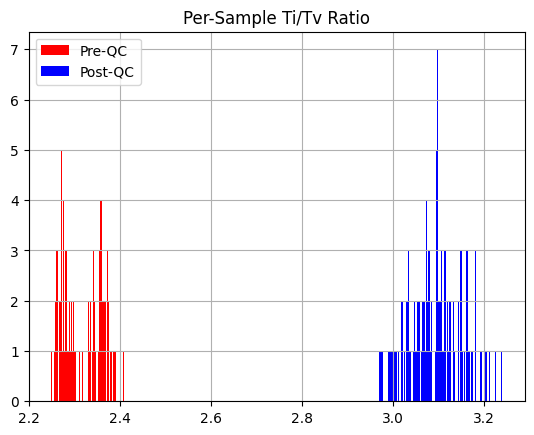

In [12]:
pre_ratios = [d["ratio"] for d in gold_stats["per_sample_ti_tv"].values()]
post_ratios = [d['ratio'] for d in post_qc_stats["per_sample_ti_tv"].values()]

plt.hist (pre_ratios, bins=100, color='r')
plt.hist (post_ratios, bins=100, color='b')
plt.grid(True)
plt.legend(['Pre-QC', 'Post-QC'])
plt.title ('Per-Sample Ti/Tv Ratio')
plt.show()